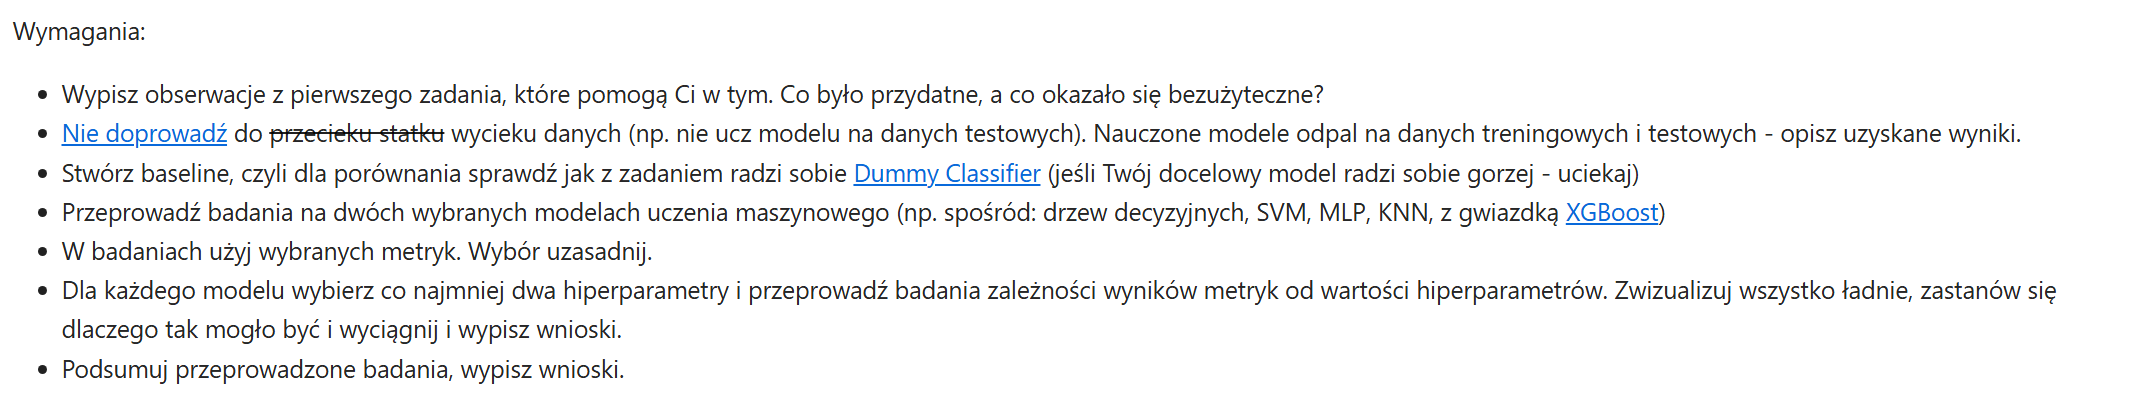

Jedyne co zauważyłem to, że nie potrzebujemy mapy ciepła, ponieważ i tak skupiamy się na jednej zmiennej.

Pobieramy potrzebne biblioteki

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [96]:
titanic_data = pd.read_csv('eda_titanic.csv');
titanic_data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Like_Jack,Like_Rose,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,0.271174,1,0,2.110213,1,0,0,0,1
1,1,1,1,0.472229,1,0,4.280593,0,0,1,0,0
2,1,3,1,0.321438,0,0,2.188856,0,0,0,0,1
3,1,1,1,0.434531,1,0,3.990834,0,0,0,0,1
4,0,3,0,0.434531,0,0,2.202765,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,0.334004,0,0,2.639057,0,0,0,0,1
887,1,1,1,0.233476,0,0,3.433987,0,1,0,0,1
888,0,3,1,0.610455,1,2,3.196630,0,0,0,0,1
889,1,1,0,0.321438,0,0,3.433987,0,0,1,0,0


Do X przypisujemy wszystkie dane na podstawie, których będziemy wróżyć czy osoba przeżyje. Do y przypisujemy wynik czyli czy dana osoba przeżyła

In [97]:
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

Tworzymy dane do trenowania oraz dane do testowania.

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True)

Najpierw sprawdzimy jak radzi sobie DummyClassifier

In [99]:
model = DummyClassifier(strategy = 'uniform')
model.fit(X_train, y_train) # uczenie
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.63      0.64      0.64       108
           1       0.44      0.44      0.44        71

    accuracy                           0.56       179
   macro avg       0.54      0.54      0.54       179
weighted avg       0.56      0.56      0.56       179



array([[69, 39],
       [40, 31]])

Jak widać dummy classifier ma accuracy na poziomie 0.56

In [111]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       108
           1       0.74      0.75      0.74        71

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



array([[89, 19],
       [18, 53]])

Nasze bazowe drzewo ma lepsze accuracy niż dummy, co jest dobrym znakiem

In [112]:
model = DecisionTreeClassifier(max_depth=3)
wyniki = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(wyniki)
print(f"srednia: {wyniki.mean():.3f}  odchylenie: {wyniki.std():.3f}")

[0.81564246 0.80898876 0.80898876 0.78089888 0.81460674]
srednia: 0.806  odchylenie: 0.013


Pomimo faktu dostrajania hiperparametrów, wynik się nie zmienił zostało tyle samoe czyli 0.806

In [113]:
from sklearn.model_selection import GridSearchCV

siatka = {
    'max_depth':         [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
    'criterion':         ['gini', 'entropy', 'log_loss'],
}

szukaj = GridSearchCV(
    DecisionTreeClassifier(random_state=0,min_samples_leaf=1),
    siatka,
    cv=5,
    scoring='accuracy'
)
szukaj.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj.best_params_)
print("wynik kroswalidacji: ", round(szukaj.best_score_, 3))
print("wynik na tescie:     ", round(szukaj.score(X_test, y_test), 3))

najlepsze ustawienia: {'criterion': 'entropy', 'max_depth': 5}
wynik kroswalidacji:  0.806
wynik na tescie:      0.788


In [103]:
tabela = pd.DataFrame(szukaj.cv_results_)
tabela = tabela[['param_max_depth', 'param_criterion',
                 'mean_test_score', 'std_test_score']]
tabela.sort_values('mean_test_score', ascending=False).head(10)

,param_max_depth,param_criterion,mean_test_score,std_test_score
21,5,entropy,0.806107,0.023488
38,5,log_loss,0.806107,0.023488
2,3,gini,0.804678,0.030840
3,4,gini,0.803319,0.021304
36,3,log_loss,0.800453,0.034007
19,3,entropy,0.800453,0.034007
5,6,gini,0.794908,0.016086
4,5,gini,0.794839,0.038856
20,4,entropy,0.792052,0.028882
37,4,log_loss,0.792052,0.028882


In [104]:
def scatterplot(df, column_name, y, category):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=column_name, y=y, hue=category, alpha=0.6)
    plt.title(f'{column_name} vs {y}')
    plt.xlabel(column_name)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

Po scatterplocie nie widać za którym parametrem chowa się entropy. Po tabli u góry widać, że niczym się nie różni od log_loss

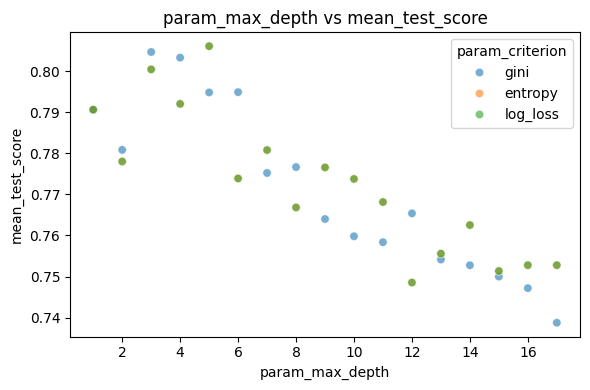

In [105]:
scatterplot(tabela, 'param_max_depth','mean_test_score','param_criterion')

Sprawdzamy bazowe KNN, ma większe accuracy niz dummy.

In [106]:
knn = KNeighborsClassifier(n_neighbors=2, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       108
           1       0.81      0.62      0.70        71

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



array([[98, 10],
       [27, 44]])

Sprawdzamy najlepsze ułożenie 'algorithm' oraz 'n_neighbors'. Wynik jest nieco gorszy niż drzewka.

In [107]:
siatka = {
  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
  'n_neighbors': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
}

szukaj = GridSearchCV(
    KNeighborsClassifier(metric='euclidean'),
    siatka,
    cv=5,
    scoring='accuracy'
)
szukaj.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj.best_params_)
print("wynik kroswalidacji: ", round(szukaj.best_score_, 3))
print("wynik na tescie:     ", round(szukaj.score(X_test, y_test), 3))

najlepsze ustawienia: {'algorithm': 'auto', 'n_neighbors': 8}
wynik kroswalidacji:  0.791
wynik na tescie:      0.804


In [108]:
tabela = pd.DataFrame(szukaj.cv_results_)
tabela = tabela[['param_algorithm', 'param_n_neighbors','mean_test_score', 'std_test_score']]
tabela.sort_values('mean_test_score', ascending=False).head(10)

,param_algorithm,param_n_neighbors,mean_test_score,std_test_score
7,auto,8,0.790752,0.035913
35,ball_tree,8,0.790752,0.035913
91,brute,8,0.790752,0.035913
63,kd_tree,8,0.790752,0.035913
21,auto,22,0.787915,0.031122
77,kd_tree,22,0.787915,0.031122
49,ball_tree,22,0.786506,0.031213
105,brute,22,0.786506,0.031213
39,ball_tree,12,0.786497,0.032243
13,auto,14,0.786487,0.029775


Na scatterplotcie widać, że różne algorytmy dają różne wyniki, ale akurat przy najlepszym ułożeniu nie miały one znaczenia.

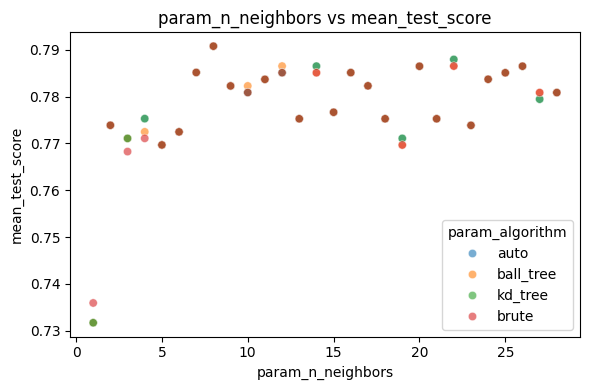

In [109]:
scatterplot(tabela, 'param_n_neighbors','mean_test_score','param_algorithm')

Martwi mnie accuracy na poziomie tylko 80%. Możliwe, że to przez źle sparsowane dane np. losowanie wieku z istniejących danych zamiast każdemu przypisać mediane. Istnieje również możliwość, że dwie identyczne osoby mogły mieć inny los tylko przez szczęście czego nie da się w sumie przewidzieć. Algorytmy miały podobne wyniki, co sugeruje problem z danymi.